# Noise Stream (SRM + EfficientNetV2-S) for Deepfake Detection

This notebook trains the SRM noise stream using:
- **Model**: `NoiseEfficientNet` (EfficientNetV2-S on SRM-filtered noise)
- **Dataset**: `InMemorySRMDataset` (all tensors pre-loaded into RAM with shard caching; SRM applied on GPU)
- **Loss**: BCEWithLogitsLoss
- **Label Mapping**: Fake = 0, Real = 1
- **Augmentation**: Symmetric (augments applied to both real and fake images)

**GPU Pipeline**: RGB → symmetric augment → scale [0,255] → SRM → clamp [-3,3] → /3 → model

**Note:** The results shown in this notebook may differ from those reported in the final report, as no fixed random seed was set during training. Variations in initialization, data shuffling, and GPU non-determinism can lead to slightly different outcomes across runs.

In [1]:
import sys, os, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from configs import NoiseStreamConfig
from models.image_detector import NoiseEfficientNet, SRMConv2d
from data_loaders.image_dataset import InMemorySRMDataset
from engine.trainer import train_one_epoch, EarlyStopping, make_noise_unpacker
from engine.evaluator import evaluate, compute_metrics
from common.augmentation import create_noise_augmentation
from common.checkpoint import save_best_model, save_checkpoint
from common.visualization import (
    plot_training_history, plot_roc_curve, plot_confusion_matrix
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.backends.cudnn.benchmark = True

Using device: cuda


## 1. Configuration

In [2]:
cfg = NoiseStreamConfig()
print(cfg)

NoiseStreamConfig(epochs=50, batch_size=64, early_stopping_patience=10, early_stopping_mode='max', label_smoothing=0.05, weight_decay=0.05, num_workers=16, noise_truncation=(-3.0, 3.0), lr_early_features=0.0001, lr_late_features=5e-05, lr_classifier=0.0001, scheduler='cosine_warm_restarts', scheduler_t0=10, scheduler_t_mult=2, scheduler_eta_min=1e-06, perf=PerformanceConfig(num_workers=16, pin_memory=True, persistent_workers=True, prefetch_factor=3, cudnn_benchmark=True, use_amp=True, compile_model=False, compile_backend='inductor'))


## 2. Datasets & DataLoaders

In [3]:
DATA_ROOT = '../data/image'
perf = cfg.perf

train_dataset = InMemorySRMDataset(os.path.join(DATA_ROOT, 'train'))
val_dataset   = InMemorySRMDataset(os.path.join(DATA_ROOT, 'val'))
test_dataset  = InMemorySRMDataset(os.path.join(DATA_ROOT, 'test'))

# With in-memory data, workers just index into a tensor — fewer needed.
loader_kwargs = dict(
    num_workers=0,
    pin_memory=perf.pin_memory,
)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,  drop_last=True, **loader_kwargs)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)

print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Loading shard ../data/image\train\_shard.pt …
  27960 samples | Fake: 13990, Real: 13970
  shape=(27960, 3, 224, 224), dtype=torch.float32, RAM=16.8 GB
Loading shard ../data/image\val\_shard.pt …
  5991 samples | Fake: 2996, Real: 2995
  shape=(5991, 3, 224, 224), dtype=torch.float32, RAM=3.6 GB
Loading shard ../data/image\test\_shard.pt …
  5981 samples | Fake: 2992, Real: 2989
  shape=(5981, 3, 224, 224), dtype=torch.float32, RAM=3.6 GB
Train batches: 436, Val: 94, Test: 94


## 3. Model, Optimizer, Scheduler

In [4]:
model = NoiseEfficientNet().to(device)
srm_layer = SRMConv2d(in_channels=3).to(device)

if perf.compile_model:
    model = torch.compile(model, backend=perf.compile_backend)
    print(f'Model compiled with backend={perf.compile_backend}')

criterion = nn.BCEWithLogitsLoss()

# 3-tier differential learning rates with selective weight decay
# (bias and normalization layers are excluded from decay)
NO_DECAY_KEYWORDS = {'bias', 'bn', 'norm'}

def build_param_groups(named_params, lr, wd):
    decay, no_decay = [], []
    for name, p in named_params:
        if not p.requires_grad:
            continue
        if any(kw in name.lower() for kw in NO_DECAY_KEYWORDS):
            no_decay.append(p)
        else:
            decay.append(p)
    groups = []
    if decay:
        groups.append({'params': decay, 'lr': lr, 'weight_decay': wd})
    if no_decay:
        groups.append({'params': no_decay, 'lr': lr, 'weight_decay': 0.0})
    return groups

param_groups = (
    build_param_groups(model.efficientnet.features[:5].named_parameters(),
                       cfg.lr_early_features, cfg.weight_decay)
    + build_param_groups(model.efficientnet.features[5:].named_parameters(),
                         cfg.lr_late_features, cfg.weight_decay)
    + build_param_groups(model.efficientnet.classifier.named_parameters(),
                         cfg.lr_classifier, cfg.weight_decay)
)

optimizer = optim.AdamW(param_groups, weight_decay=0.0)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=cfg.scheduler_t0, T_mult=cfg.scheduler_t_mult,
    eta_min=cfg.scheduler_eta_min,
)

scaler = torch.amp.GradScaler('cuda', enabled=perf.use_amp)
print(f'AMP enabled: {perf.use_amp}')

sym_augment = create_noise_augmentation().to(device)

train_unpack = make_noise_unpacker(srm_layer, gpu_augment=sym_augment,
                                   label_smoothing=cfg.label_smoothing)
val_unpack   = make_noise_unpacker(srm_layer, label_smoothing=0.0)

print('Model, optimizer, and scheduler ready.')

AMP enabled: True
Model, optimizer, and scheduler ready.


## 4. Training Loop

In [5]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
early_stop = EarlyStopping(patience=cfg.early_stopping_patience, mode=cfg.early_stopping_mode)
best_val_auc = 0.0

for epoch in range(cfg.epochs):
    print(f'\nEpoch {epoch+1}/{cfg.epochs}')

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        unpack_fn=train_unpack,
        scaler=scaler, use_amp=perf.use_amp,
    )

    val_results = evaluate(
        model, val_loader, criterion, device,
        unpack_fn=val_unpack,
        use_amp=perf.use_amp,
    )

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_results['val_loss'])
    history['val_acc'].append(val_results['accuracy'])
    history['val_auc'].append(val_results['roc_auc'])

    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"  Val   Loss: {val_results['val_loss']:.4f} | Acc: {val_results['accuracy']*100:.2f}% | AUC: {val_results['roc_auc']:.4f}")

    if val_results['roc_auc'] > best_val_auc:
        best_val_auc = val_results['roc_auc']
        save_best_model(model, '../saved_models/best_noise_efficientnet.pth', epoch, val_results)

    if early_stop(val_results['roc_auc']):
        break

print(f'\nBest Val AUC: {best_val_auc:.4f}')


Epoch 1/50


  Train Loss: 0.6257 | Acc: 65.99%
  Val   Loss: 0.5167 | Acc: 74.19% | AUC: 0.8286
Best model saved to ../saved_models/best_noise_efficientnet.pth

Epoch 2/50


  Train Loss: 0.5561 | Acc: 73.87%
  Val   Loss: 0.4361 | Acc: 79.64% | AUC: 0.8829
Best model saved to ../saved_models/best_noise_efficientnet.pth

Epoch 3/50


  Train Loss: 0.5048 | Acc: 78.53%
  Val   Loss: 0.3890 | Acc: 82.92% | AUC: 0.9088
Best model saved to ../saved_models/best_noise_efficientnet.pth

Epoch 4/50


  Train Loss: 0.4703 | Acc: 81.63%
  Val   Loss: 0.3727 | Acc: 83.27% | AUC: 0.9168
Best model saved to ../saved_models/best_noise_efficientnet.pth

Epoch 5/50


...

  Train Loss: 0.2391 | Acc: 97.67%
  Val   Loss: 0.2766 | Acc: 89.98% | AUC: 0.9544
EarlyStopping counter: 6/10

Epoch 29/50


  Train Loss: 0.2382 | Acc: 97.72%
  Val   Loss: 0.2714 | Acc: 90.30% | AUC: 0.9564
EarlyStopping counter: 7/10

Epoch 30/50


  Train Loss: 0.2387 | Acc: 97.65%
  Val   Loss: 0.2765 | Acc: 89.97% | AUC: 0.9562
EarlyStopping counter: 8/10

Epoch 31/50


  Train Loss: 0.2690 | Acc: 95.81%
  Val   Loss: 0.2774 | Acc: 89.67% | AUC: 0.9572
EarlyStopping counter: 9/10

Epoch 32/50


  Train Loss: 0.2683 | Acc: 95.82%
  Val   Loss: 0.2838 | Acc: 89.18% | AUC: 0.9520
EarlyStopping counter: 10/10
Early stopping triggered!

Best Val AUC: 0.9604


## 5. Test Evaluation

In [6]:
from common.checkpoint import load_model_weights_only

load_model_weights_only(model, '../saved_models/best_noise_efficientnet.pth', device=device)

test_results = evaluate(
    model, test_loader, criterion, device, unpack_fn=val_unpack,
    use_amp=perf.use_amp,
)

# Convert P(Real) → P(Fake) for compute_metrics (binary model outputs P(Real))
probs_fake = 1.0 - test_results['all_probs']

metrics = compute_metrics(
    test_results['all_labels'], test_results['all_preds'], probs_fake,
)

print(f"Test Accuracy:  {metrics['accuracy']*100:.2f}%")
print(f"Test Precision: {metrics['precision']:.4f}")
print(f"Test Recall:    {metrics['recall']:.4f}")
print(f"Test F1:        {metrics['f1']:.4f}")
print(f"Test AUC-ROC:   {test_results['roc_auc']:.4f}")
print(f"Test AUC-PR:    {test_results['pr_auc']:.4f}")

Model weights loaded from ../saved_models/best_noise_efficientnet.pth


Test Accuracy:  90.42%
Test Precision: 0.9138
Test Recall:    0.8927
Test F1:        0.9031
Test AUC-ROC:   0.9652
Test AUC-PR:    0.9672


## 6. Visualization

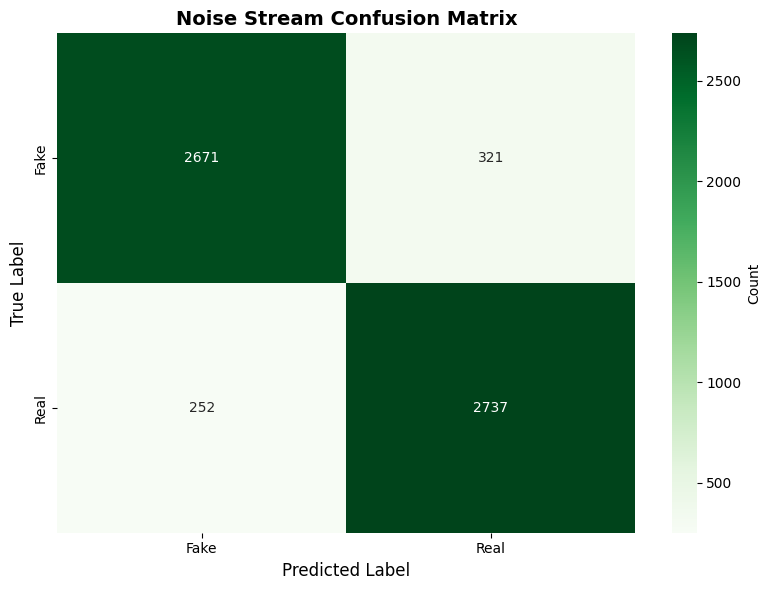

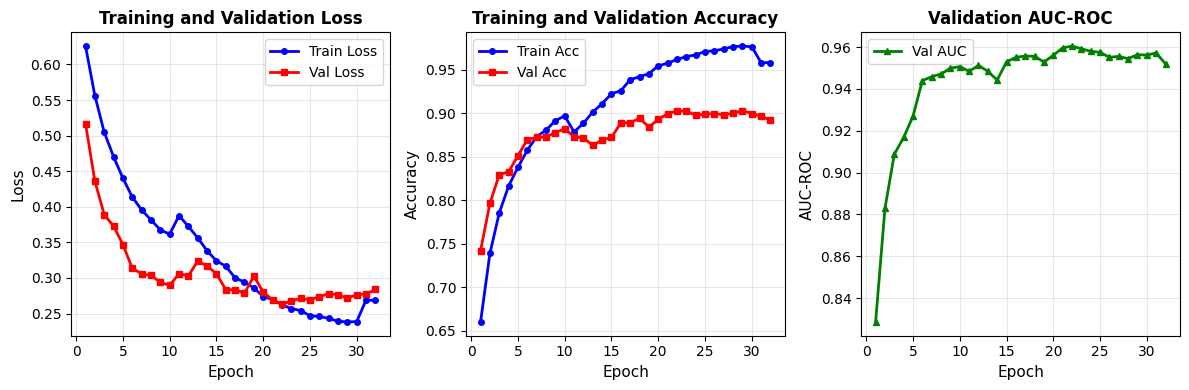

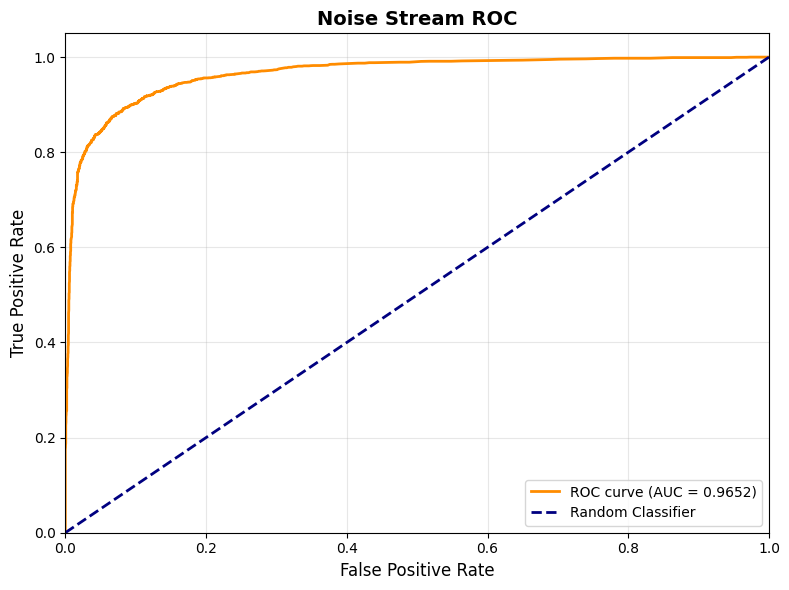

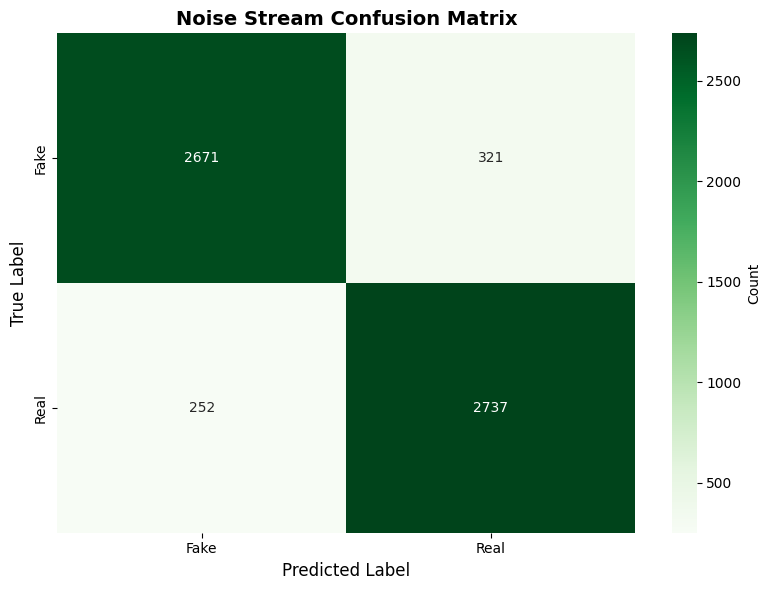

In [7]:
plot_training_history(
    history['train_loss'], history['val_loss'],
    history['train_acc'], history['val_acc'], history['val_auc'],
    save_path='../results/noise_training_curves.png',
)

labels_fake = (test_results['all_labels'] == 0).astype(int)
probs_fake  = 1.0 - test_results['all_probs']

plot_roc_curve(labels_fake, probs_fake,
               title='Noise Stream ROC', save_path='../results/noise_roc.png')
plot_confusion_matrix(test_results['all_labels'], test_results['all_preds'],
                      title='Noise Stream Confusion Matrix',
                      save_path='../results/noise_cm.png')